In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random

c:\Users\top\Desktop\shemo_env\shemo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [4]:
whisper_large_processor = WhisperProcessor.from_pretrained('whisper_tiny')

In [5]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_large_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))

In [6]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample
    

Shemo = AudioDataSet(features, labels)


# Split the dataset into training and validation sets
trainset, valset = random_split(Shemo, [len(Shemo)-500, 500])


# Example of using DataLoader for batching
train_loader = DataLoader(trainset, batch_size=4, shuffle=True)
val_loader = DataLoader(valset, batch_size=4, shuffle=False)

In [7]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  best_val_accuracy = 0.0
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      output = model(inputs)
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)
    valid_accuracy = num_correct / num_examples

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {valid_accuracy : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        current_patience = 0
    else:
        current_patience += 1

    if valid_accuracy > best_val_accuracy:
      best_val_accuracy = valid_accuracy
      torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [8]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    output = model(inputs)
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

In [9]:
reset_seed(42)
whisper_large_path = 'whisper_tiny'
whisper_encoder = WhisperForAudioClassification.from_pretrained(
    whisper_large_path
).encoder

whisper_all = WhisperForAudioClassification.from_pretrained(
    whisper_large_path
)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.projector.weight', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.projector.weight', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
whisper_encoder

WhisperEncoder(
  (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
  (embed_positions): Embedding(1500, 384)
  (layers): ModuleList(
    (0-3): 4 x WhisperEncoderLayer(
      (self_attn): WhisperSdpaAttention(
        (k_proj): Linear(in_features=384, out_features=384, bias=False)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (activation_fn): GELUActivation()
      (fc1): Linear(in_features=384, out_features=1536, bias=True)
      (fc2): Linear(in_features=1536, out_features=384, bias=True)
      (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    )
  )
  (layer_norm): LayerNorm((384,), eps=1e-05, elementw

In [57]:
whisper_encoder

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 384)
    (layers): ModuleList(
      (0-3): 4 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=384, out_features=384, bias=False)
          (v_proj): Linear(in_features=384, out_features=384, bias=True)
          (q_proj): Linear(in_features=384, out_features=384, bias=True)
          (out_proj): Linear(in_features=384, out_features=384, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_

In [59]:
print(inspect.getsource(whisper_encoder.forward))

    @add_start_docstrings_to_model_forward(WHISPER_ENCODER_INPUTS_DOCSTRING)
    @replace_return_docstrings(output_type=SequenceClassifierOutput, config_class=_CONFIG_FOR_DOC)
    def forward(
        self,
        input_features: Optional[torch.LongTensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_outputs: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        labels: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple[torch.Tensor], SequenceClassifierOutput]:
        r"""
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1

In [26]:
import inspect

In [47]:
print(inspect.getsource(whisper_encoder.forward))

    def forward(
        self,
        input_features,
        attention_mask=None,
        head_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
    ):
        r"""
        Args:
            input_features (`torch.LongTensor` of shape `(batch_size, feature_size, sequence_length)`):
                Float values of mel features extracted from the raw speech waveform. Raw speech waveform can be
                obtained by loading a `.flac` or `.wav` audio file into an array of type `List[float]` or a
                `numpy.ndarray`, *e.g.* via the soundfile library (`pip install soundfile`). To prepare the array into
                `input_features`, the [`AutoFeatureExtractor`] should be used for extracting the mel features, padding
                and conversion into a tensor of type `torch.FloatTensor`. See [`~WhisperFeatureExtractor.__call__`]
            attention_mask (`torch.Tensor`)`, *optional*):
                Whisper does

In [63]:
whisper_encoder(torch.unsqueeze(features[0], dim=0)).last_hidden_state.shape

torch.Size([1, 1500, 384])

In [69]:
whisper_all.projector(whisper_encoder(torch.unsqueeze(features[0], dim=0)).last_hidden_state).mean(dim=1).shape

torch.Size([1, 256])

In [68]:
whisper_all.projector

Linear(in_features=384, out_features=256, bias=True)

In [46]:
one = torch.ones(2, 5)

In [34]:
two = torch.Tensor([[0.5], [3]])

In [44]:
one

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [37]:
two

tensor([[0.5000],
        [3.0000]])

In [58]:
F.softmax(two, dim=0)

tensor([[0.0759],
        [0.9241]])

In [47]:
three = one*two

In [48]:
three

tensor([[0.5000, 0.5000, 0.5000, 0.5000, 0.5000],
        [3.0000, 3.0000, 3.0000, 3.0000, 3.0000]])

In [52]:
three.mean(dim=0)

tensor([1.7500, 1.7500, 1.7500, 1.7500, 1.7500])

In [42]:
pro = nn.Linear(in_features=5, out_features=3)

In [45]:
pro(one)

tensor([[0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361],
        [0.7005, 0.4952, 0.6361]], grad_fn=<AddmmBackward0>)

In [8]:
reset_seed(42)

class WhisAttSumModel (nn.Module):
  def __init__(self):
    super(WhisAttSumModel, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.classifier = torch.nn.Linear(in_features=256, out_features=5)

  def forward(self, x):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = self.layernorm(out)
    attention_scores = self.attention_scorer(out)
    attention_weights = F.softmax(attention_scores, dim=1)
    weighted_output = out*attention_weights
    weighted_mean_pooled_output = weighted_output.sum(dim=1)
    out = self.classifier(weighted_mean_pooled_output)

    return out, attention_weights

# Attention_norm_oneAtt

In [107]:
reset_seed(42)

model = WhisAttSumModel()

for param in model.parameters():
    param.requires_grad = False

for param in model.projector.parameters():
    param.requires_grad = True

for param in model.attention_scorer.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requeres_grad = True

for param in model.layernorm.parameters():
    param.requires_grad = True

model.to(device)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.bias', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.bias', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WhisAttSumModel(
  (whisperencoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affin

In [108]:
reset_seed(42)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

training_losses2, valid_losses2 = train(model, 'whisper_att_sum_norm', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

Epoch: 1 finished in 131.43 seconds, Training Loss:  0.82, Validation Loss: 0.52, Validation Accuracy:  0.82


Epoch: 2 finished in 131.47 seconds, Training Loss:  0.48, Validation Loss: 0.42, Validation Accuracy:  0.88


Epoch: 3 finished in 131.65 seconds, Training Loss:  0.39, Validation Loss: 0.41, Validation Accuracy:  0.88


Epoch: 4 finished in 131.65 seconds, Training Loss:  0.35, Validation Loss: 0.41, Validation Accuracy:  0.85


Epoch: 5 finished in 131.71 seconds, Training Loss:  0.31, Validation Loss: 0.51, Validation Accuracy:  0.80


Epoch: 6 finished in 131.76 seconds, Training Loss:  0.27, Validation Loss: 0.41, Validation Accuracy:  0.86


Epoch: 7 finished in 131.44 seconds, Training Loss:  0.25, Validation Loss: 0.41, Validation Accuracy:  0.87


Epoch: 8 finished in 131.56 seconds, Training Loss:  0.22, Validation Loss: 0.41, Validation Accuracy:  0.86


Epoch: 9 finished in 131.59 seconds, Training Loss:  0.19, Validation Loss: 0.42, Validation Accuracy:  0.84


Epoch: 10 finished in 131.51 seconds, Training Loss:  0.17, Validation Loss: 0.44, Validation Accuracy:  0.84
Each epoch took 131.58 seconds in average.


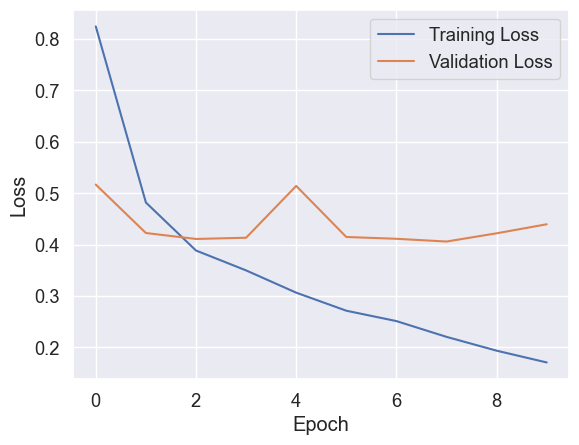

In [109]:
plt.plot(training_losses2, label='Training Loss')
plt.plot(valid_losses2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

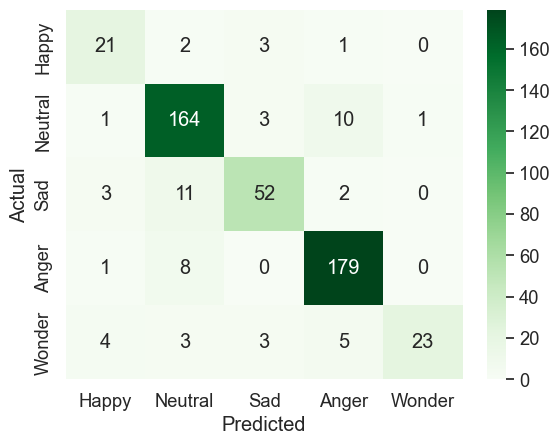

Testing finished with Loss:  0.41 | U_Accuracy:  0.80 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.88
Accuracy per class:
Class 0: 0.7777777777777778
Class 1: 0.9162011173184358
Class 2: 0.7647058823529411
Class 3: 0.9521276595744681
Class 4: 0.6052631578947368


In [110]:
model.load_state_dict(torch.load('whisper_att_sum_norm.bin'))
test(model, torch.nn.CrossEntropyLoss(), val_loader)

In [137]:
model = WhisAttSumModel().to(device)
model.load_state_dict(torch.load('whisper_att_sum_norm.bin'))

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.weight', 'model.classifier.weight', 'model.projector.bias', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.weight', 'model.classifier.weight', 'model.projector.bias', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [138]:
atts1 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[23].to("cuda"), dim=0))[-1], dim=0), dim=-1)
atts1.detach().to('cpu').numpy()

array([5.3570944e-05, 9.7761033e-03, 1.1170485e-04, ..., 2.6829930e-06,
       1.3020286e-05, 4.0560215e-05], dtype=float32)

In [139]:
atts2 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[30].to("cuda"), dim=0))[-1], dim=0), dim=-1)
atts2.detach().to('cpu').numpy()

array([3.7324175e-05, 2.0750698e-03, 1.3142613e-03, ..., 4.1219623e-06,
       1.6957065e-05, 5.4010918e-05], dtype=float32)

In [140]:
atts3 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[41].to("cuda"), dim=0))[-1], dim=0), dim=-1)
atts3.detach().to('cpu').numpy()

array([1.9592288e-04, 4.9005833e-04, 2.2215297e-04, ..., 1.0993395e-05,
       4.1918287e-05, 1.6126038e-04], dtype=float32)

In [141]:
atts4 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[0].to("cuda"), dim=0))[-1], dim=0), dim=-1)
atts4.detach().to('cpu').numpy()

array([6.7900990e-05, 4.9845563e-05, 6.3466992e-05, ..., 7.3281262e-06,
       2.7505053e-05, 8.7434317e-05], dtype=float32)

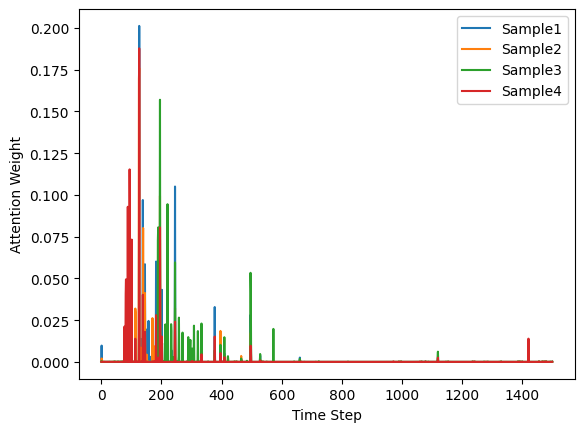

In [142]:
plt.plot(atts1.detach().to('cpu').numpy(), label="Sample1")
plt.plot(atts2.detach().to('cpu').numpy(), label="Sample2")
plt.plot(atts3.detach().to('cpu').numpy(), label="Sample3")
plt.plot(atts4.detach().to('cpu').numpy(), label="Sample4")
plt.xlabel('Time Step')
plt.ylabel('Attention Weight')
plt.legend()
plt.show()

# Two Attention Sum

In [90]:
reset_seed(42)

class WhisAttSumModel2Att (nn.Module):
  def __init__(self):
    super(WhisAttSumModel2Att, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    self.attention_scorer1 = nn.Linear(in_features=256, out_features=1, bias=True)
    self.attention_scorer2 = nn.Linear(in_features=256, out_features=1, bias=True)
    self.classifier = torch.nn.Linear(in_features=256, out_features=5)

  def forward(self, x):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = self.layernorm(out)
    attention_scores1 = self.attention_scorer1(out)
    attention_weights1 = F.softmax(attention_scores1, dim=1)
    weighted_output1 = out*attention_weights1
    weighted_mean_pooled_output1 = weighted_output1.sum(dim=1)

    attention_scores2 = self.attention_scorer2(out)
    attention_weights2 = F.softmax(attention_scores2, dim=1)
    weighted_output2 = out*attention_weights2
    weighted_mean_pooled_output2 = weighted_output2.sum(dim=1)

    weighted_mean_pooled_output = (weighted_mean_pooled_output1 + weighted_mean_pooled_output2)/2
    out = self.classifier(weighted_mean_pooled_output)

    return out

In [92]:
reset_seed(42)

model = WhisAttSumModel2Att()

for param in model.parameters():
    param.requires_grad = False

for param in model.projector.parameters():
    param.requires_grad = True

for param in model.attention_scorer1.parameters():
    param.requires_grad = True

for param in model.attention_scorer2.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requeres_grad = True

for param in model.layernorm.parameters():
    param.requeire_grad = True

model.to(device)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.bias', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.bias', 'model.classifier.bias', 'model.classifier.weight', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WhisAttSumModel2Att(
  (whisperencoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_a

In [93]:
reset_seed(42)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

training_losses3, valid_losses3 = train(model, 'whisper_att_sum_norm_twoattsum', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

Epoch: 1 finished in 131.90 seconds, Training Loss:  0.80, Validation Loss: 0.48, Validation Accuracy:  0.84


Epoch: 2 finished in 131.86 seconds, Training Loss:  0.47, Validation Loss: 0.41, Validation Accuracy:  0.86


Epoch: 3 finished in 131.78 seconds, Training Loss:  0.38, Validation Loss: 0.41, Validation Accuracy:  0.88


Epoch: 4 finished in 131.79 seconds, Training Loss:  0.35, Validation Loss: 0.41, Validation Accuracy:  0.86


Epoch: 5 finished in 131.71 seconds, Training Loss:  0.30, Validation Loss: 0.52, Validation Accuracy:  0.79


Epoch: 6 finished in 131.76 seconds, Training Loss:  0.27, Validation Loss: 0.41, Validation Accuracy:  0.87


Epoch: 7 finished in 131.58 seconds, Training Loss:  0.25, Validation Loss: 0.41, Validation Accuracy:  0.87


Epoch: 8 finished in 131.61 seconds, Training Loss:  0.22, Validation Loss: 0.41, Validation Accuracy:  0.85


Epoch: 9 finished in 131.56 seconds, Training Loss:  0.20, Validation Loss: 0.42, Validation Accuracy:  0.84


Epoch: 10 finished in 131.49 seconds, Training Loss:  0.18, Validation Loss: 0.44, Validation Accuracy:  0.84
Each epoch took 131.70 seconds in average.


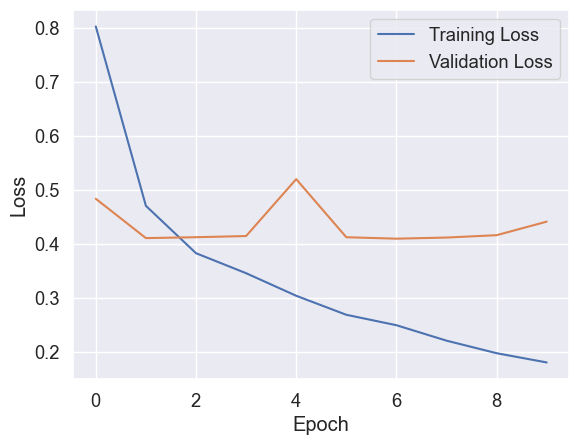

In [94]:
plt.plot(training_losses3, label='Training Loss')
plt.plot(valid_losses3, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

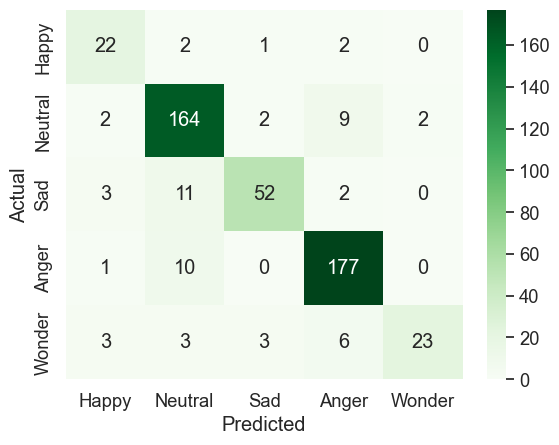

Testing finished with Loss:  0.41 | U_Accuracy:  0.81 | W_Accuracy:  0.88 | Precision:  0.88 | Recall:  0.88 | f1:  0.87
Accuracy per class:
Class 0: 0.8148148148148148
Class 1: 0.9162011173184358
Class 2: 0.7647058823529411
Class 3: 0.9414893617021277
Class 4: 0.6052631578947368


In [95]:
model.load_state_dict(torch.load('whisper_att_sum_norm_twoattsum.bin'))
test(model, torch.nn.CrossEntropyLoss(), val_loader)

# head4, embed 128, drop 0.5

In [51]:
reset_seed(42)

class WhisAttSumModelhead (nn.Module):
  def __init__(self, heads=2, dropout = 0.5, dimention=128):
    super(WhisAttSumModelhead, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    # self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.multihead = nn.MultiheadAttention(embed_dim=dimention, kdim=256, vdim=256, num_heads=heads, batch_first=True, dropout=dropout)
    self.classifier = torch.nn.Linear(in_features=dimention, out_features=5)
    self.attparam = nn.Parameter(torch.rand(1, dimention))

  def forward(self, x):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = self.layernorm(out)
    # #print(f'out{out.shape}')
    # attention_scores = (out*self.attparam).sum(dim=-1)
    # attention_scores = torch.unsqueeze(attention_scores, dim=-1)
    # #print(f'socers{attention_scores.shape}')
    # attention_weights = F.softmax(attention_scores, dim=1)
    # #print(f'weights{attention_weights.shape}')
    # weighted_output = out*attention_weights
    stacked_param = self.attparam.unsqueeze(0).repeat(x.size()[0], 1, 1)
    weighted_output, attn_output_weights= self.multihead(query=stacked_param , key=out, value=out, average_attn_weights=False)
    # weighted_mean_pooled_output = weighted_output.sum(dim=1)
    out = self.classifier(weighted_output.squeeze(dim=1))

    return out, attn_output_weights

In [22]:
reset_seed(42)

model = WhisAttSumModelhead(heads=4, dropout=0.5)
reset_seed(42)
for param in model.parameters():
    param.requires_grad = False

for param in model.projector.parameters():
    param.requires_grad = True

for param in model.layernorm.parameters():
    param.requires_grad = True

model.attparam.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

for param in model.multihead.parameters():
    param.requires_grad = True

model.to(device)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.weight', 'model.projector.bias', 'model.projector.weight', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.weight', 'model.projector.bias', 'model.projector.weight', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WhisAttSumModelhead(
  (whisperencoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_a

In [23]:
modelparam1 = model.attparam

In [24]:
modelparam3 == modelparam1

tensor([[True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True, True, True, True, True,
         True, True, True, True, True, True, True, True]], device='cuda:0')

In [25]:
reset_seed(42)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

training_losses7, valid_losses7 = train(model, 'whisper_att_head2-drop0.5-dim128', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

Epoch: 1 finished in 131.86 seconds, Training Loss:  0.85, Validation Loss: 0.51, Validation Accuracy:  0.82


Epoch: 2 finished in 131.69 seconds, Training Loss:  0.48, Validation Loss: 0.40, Validation Accuracy:  0.85


Epoch: 3 finished in 131.83 seconds, Training Loss:  0.37, Validation Loss: 0.37, Validation Accuracy:  0.88


Epoch: 4 finished in 131.77 seconds, Training Loss:  0.32, Validation Loss: 0.42, Validation Accuracy:  0.86


Epoch: 5 finished in 131.77 seconds, Training Loss:  0.27, Validation Loss: 0.49, Validation Accuracy:  0.81


Epoch: 6 finished in 131.71 seconds, Training Loss:  0.21, Validation Loss: 0.40, Validation Accuracy:  0.87


Epoch: 7 finished in 131.78 seconds, Training Loss:  0.20, Validation Loss: 0.43, Validation Accuracy:  0.87


Epoch: 8 finished in 131.77 seconds, Training Loss:  0.15, Validation Loss: 0.41, Validation Accuracy:  0.89


Epoch: 9 finished in 131.72 seconds, Training Loss:  0.11, Validation Loss: 0.43, Validation Accuracy:  0.87


Epoch: 10 finished in 131.83 seconds, Training Loss:  0.11, Validation Loss: 0.47, Validation Accuracy:  0.87
Each epoch took 131.77 seconds in average.


In [26]:
model2param = model.attparam

In [27]:
model2param == modelparam3

tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, F

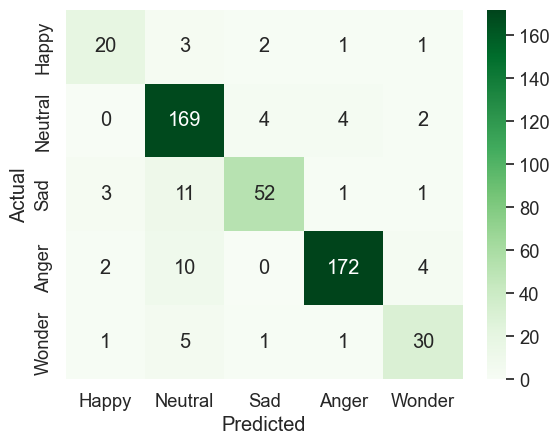

Testing finished with Loss:  0.41 | U_Accuracy:  0.83 | W_Accuracy:  0.89 | Precision:  0.89 | Recall:  0.89 | f1:  0.89
Accuracy per class:
Class 0: 0.7407407407407407
Class 1: 0.9441340782122905
Class 2: 0.7647058823529411
Class 3: 0.9148936170212766
Class 4: 0.7894736842105263


In [23]:
model.load_state_dict(torch.load('whisper_att_head2-drop0.5-dim128.bin'))
test(model, torch.nn.CrossEntropyLoss(), val_loader)

In [143]:
model = WhisAttSumModelhead(heads=4, dropout=0.5).to(device)
model.load_state_dict(torch.load('whisper_att_head2-drop0.5-dim128.bin'))

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.weight', 'model.classifier.weight', 'model.projector.bias', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.projector.weight', 'model.classifier.weight', 'model.projector.bias', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [149]:
atts1 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[23].to("cuda"), dim=0))[-1], dim=2), dim=0)
atts1.detach().to('cpu').numpy()

array([[1.3336701e-04, 7.1403751e-04, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 1.7662421e-04],
       [1.2919947e-04, 1.3696048e-02, 0.0000000e+00, ..., 9.4584093e-06,
        0.0000000e+00, 9.5838441e-05],
       [6.8213610e-04, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        8.9342961e-05, 7.2286988e-04],
       [0.0000000e+00, 8.8836616e-03, 1.8568009e-02, ..., 6.2064628e-06,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [148]:
atts2 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[30].to("cuda"), dim=0))[-1], dim=2), dim=0)
atts2.detach().to('cpu').numpy()

array([[2.4788245e-04, 2.5597536e-03, 1.1428094e-03, ..., 4.4050681e-05,
        3.0539388e-05, 0.0000000e+00],
       [4.2032666e-06, 7.4394634e-03, 3.4453836e-04, ..., 0.0000000e+00,
        6.8506074e-07, 0.0000000e+00],
       [0.0000000e+00, 1.3497064e-04, 2.1243657e-03, ..., 0.0000000e+00,
        0.0000000e+00, 3.5645950e-03],
       [3.0467417e-03, 2.8860144e-02, 0.0000000e+00, ..., 1.7122851e-05,
        0.0000000e+00, 2.8886285e-05]], dtype=float32)

In [146]:
atts3 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[41].to("cuda"), dim=0))[-1], dim=2), dim=0)
atts3.detach().to('cpu').numpy()

array([[0.0000000e+00, 0.0000000e+00, 1.6419146e-04, ..., 0.0000000e+00,
        2.2533025e-04, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 4.8292000e-05, ..., 1.0714253e-06,
        1.9426072e-06, 9.5749801e-06],
       [7.3860859e-04, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        4.3303487e-05, 2.8613029e-04],
       [0.0000000e+00, 9.8055666e-03, 0.0000000e+00, ..., 5.2156258e-05,
        3.9634291e-05, 9.0263973e-05]], dtype=float32)

In [147]:
atts4 = torch.squeeze(torch.squeeze(model(torch.unsqueeze(features[0].to("cuda"), dim=0))[-1], dim=2), dim=0)
atts4.detach().to('cpu').numpy()

array([[2.4339473e-05, 3.7502861e-05, 3.6144382e-05, ..., 1.8835946e-05,
        1.2455606e-05, 4.2783602e-05],
       [1.8334957e-05, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        2.5233910e-06, 0.0000000e+00],
       [3.5598243e-03, 7.7074539e-04, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 9.6270343e-04],
       [9.4044924e-04, 0.0000000e+00, 1.5359069e-02, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

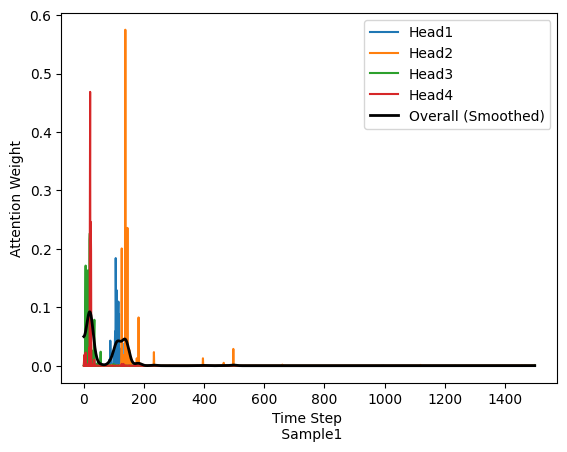

In [150]:
# Convert the attention weights to numpy arrays
head1 = atts1[0].detach().to('cpu').numpy()
head2 = atts1[1].detach().to('cpu').numpy()
head3 = atts1[2].detach().to('cpu').numpy()
head4 = atts1[3].detach().to('cpu').numpy()

# Plot individual head attention weights
plt.plot(head1, label="Head1")
plt.plot(head2, label="Head2")
plt.plot(head3, label="Head3")
plt.plot(head4, label="Head4")

# Calculate the overall attention weight
overall_attention = head1 + head2 + head3 + head4

# Apply Gaussian smoothing to the overall attention weights
smoothed_attention = gaussian_filter1d(overall_attention, sigma=10)

# Plot the smoothed overall attention weights
plt.plot(smoothed_attention, label="Overall (Smoothed)", linewidth=2, color='black')

# Label the axes
plt.xlabel('Time Step \n Sample1')
plt.ylabel('Attention Weight')

# Show the legend
plt.legend()

# Display the plot
plt.show()

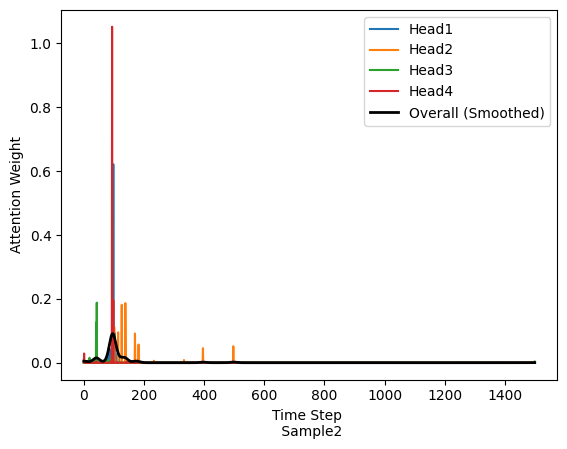

In [152]:
# Convert the attention weights to numpy arrays
head1 = atts2[0].detach().to('cpu').numpy()
head2 = atts2[1].detach().to('cpu').numpy()
head3 = atts2[2].detach().to('cpu').numpy()
head4 = atts2[3].detach().to('cpu').numpy()

# Plot individual head attention weights
plt.plot(head1, label="Head1")
plt.plot(head2, label="Head2")
plt.plot(head3, label="Head3")
plt.plot(head4, label="Head4")

# Calculate the overall attention weight
overall_attention = head1 + head2 + head3 + head4

# Apply Gaussian smoothing to the overall attention weights
smoothed_attention = gaussian_filter1d(overall_attention, sigma=10)

# Plot the smoothed overall attention weights
plt.plot(smoothed_attention, label="Overall (Smoothed)", linewidth=2, color='black')

# Label the axes
plt.xlabel('Time Step \n Sample2')
plt.ylabel('Attention Weight')

# Show the legend
plt.legend()

# Display the plot
plt.show()

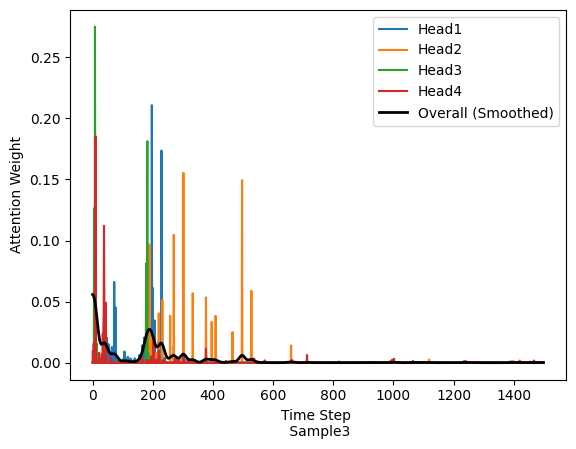

In [153]:
# Convert the attention weights to numpy arrays
head1 = atts3[0].detach().to('cpu').numpy()
head2 = atts3[1].detach().to('cpu').numpy()
head3 = atts3[2].detach().to('cpu').numpy()
head4 = atts3[3].detach().to('cpu').numpy()

# Plot individual head attention weights
plt.plot(head1, label="Head1")
plt.plot(head2, label="Head2")
plt.plot(head3, label="Head3")
plt.plot(head4, label="Head4")

# Calculate the overall attention weight
overall_attention = head1 + head2 + head3 + head4

# Apply Gaussian smoothing to the overall attention weights
smoothed_attention = gaussian_filter1d(overall_attention, sigma=10)

# Plot the smoothed overall attention weights
plt.plot(smoothed_attention, label="Overall (Smoothed)", linewidth=2, color='black')

# Label the axes
plt.xlabel('Time Step \n Sample3')
plt.ylabel('Attention Weight')

# Show the legend
plt.legend()

# Display the plot
plt.show()

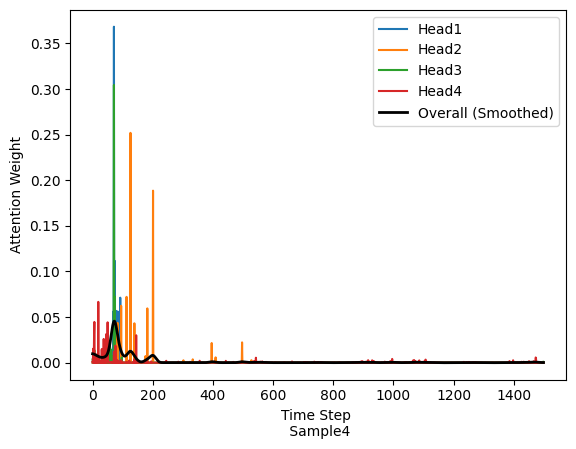

In [159]:
from scipy.ndimage import gaussian_filter1d

# Convert the attention weights to numpy arrays
head1 = atts4[0].detach().to('cpu').numpy()
head2 = atts4[1].detach().to('cpu').numpy()
head3 = atts4[2].detach().to('cpu').numpy()
head4 = atts4[3].detach().to('cpu').numpy()

# Plot individual head attention weights
plt.plot(head1, label="Head1")
plt.plot(head2, label="Head2")
plt.plot(head3, label="Head3")
plt.plot(head4, label="Head4")

# Calculate the overall attention weight
overall_attention = head1 + head2 + head3 + head4

# Apply Gaussian smoothing to the overall attention weights
smoothed_attention = gaussian_filter1d(overall_attention, sigma=10)

# Plot the smoothed overall attention weights
plt.plot(smoothed_attention, label="Overall (Smoothed)", linewidth=2, color='black')

# Label the axes
plt.xlabel('Time Step \n Sample4')
plt.ylabel('Attention Weight')

# Show the legend
plt.legend()

# Display the plot
plt.show()

In [136]:
labels.index(0),labels.index(1), labels.index(2), labels.index(3), labels.index(4)

(23, 30, 41, 0, 64)

# Same best mutlihead without learnable parameter

In [15]:
reset_seed(42)

class WhisAttSumModelhead (nn.Module):
  def __init__(self, heads=2, dropout = 0.5, dimention=128):
    super(WhisAttSumModelhead, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.layernorm = nn.LayerNorm(256)
    # self.attention_scorer = nn.Linear(in_features=256, out_features=1, bias=True)
    self.multihead = nn.MultiheadAttention(embed_dim=dimention, kdim=256, vdim=256, num_heads=heads, batch_first=True, dropout=dropout)
    self.classifier = torch.nn.Linear(in_features=dimention, out_features=5)
    self.attparam = nn.Parameter(torch.rand(1, dimention))

  def forward(self, x):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out = self.layernorm(out)
    # #print(f'out{out.shape}')
    # attention_scores = (out*self.attparam).sum(dim=-1)
    # attention_scores = torch.unsqueeze(attention_scores, dim=-1)
    # #print(f'socers{attention_scores.shape}')
    # attention_weights = F.softmax(attention_scores, dim=1)
    # #print(f'weights{attention_weights.shape}')
    # weighted_output = out*attention_weights
    stacked_param = self.attparam.unsqueeze(0).repeat(x.size()[0], 1, 1)
    weighted_output, attn_output_weights= self.multihead(query=stacked_param , key=out, value=out)
    # weighted_mean_pooled_output = weighted_output.sum(dim=1)
    out = self.classifier(weighted_output.squeeze(dim=1))

    return out

In [16]:
reset_seed(42)

model = WhisAttSumModelhead(heads=4, dropout=0.5)
reset_seed(42)
for param in model.parameters():
    param.requires_grad = False

for param in model.projector.parameters():
    param.requires_grad = True

for param in model.layernorm.parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

for param in model.multihead.parameters():
    param.requires_grad = True

model.to(device)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.weight', 'model.projector.bias', 'model.projector.weight', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.weight', 'model.projector.bias', 'model.projector.weight', 'model.classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WhisAttSumModelhead(
  (whisperencoder): WhisperEncoder(
    (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 768)
    (layers): ModuleList(
      (0-11): 12 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_a

In [17]:
reset_seed(42)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

training_losses7, valid_losses7 = train(model, 'whisper_att_head_no_param', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

Epoch: 1 finished in 131.86 seconds, Training Loss:  0.85, Validation Loss: 0.52, Validation Accuracy:  0.82


Epoch: 2 finished in 131.43 seconds, Training Loss:  0.48, Validation Loss: 0.39, Validation Accuracy:  0.85


Epoch: 3 finished in 131.82 seconds, Training Loss:  0.37, Validation Loss: 0.37, Validation Accuracy:  0.88


Epoch: 4 finished in 131.64 seconds, Training Loss:  0.32, Validation Loss: 0.42, Validation Accuracy:  0.86


Epoch: 5 finished in 131.74 seconds, Training Loss:  0.27, Validation Loss: 0.48, Validation Accuracy:  0.81


Epoch: 6 finished in 131.84 seconds, Training Loss:  0.21, Validation Loss: 0.40, Validation Accuracy:  0.87


Epoch: 7 finished in 131.86 seconds, Training Loss:  0.20, Validation Loss: 0.43, Validation Accuracy:  0.87


Epoch: 8 finished in 131.67 seconds, Training Loss:  0.15, Validation Loss: 0.41, Validation Accuracy:  0.89


Epoch: 9 finished in 132.03 seconds, Training Loss:  0.11, Validation Loss: 0.43, Validation Accuracy:  0.87


Epoch: 10 finished in 131.88 seconds, Training Loss:  0.11, Validation Loss: 0.46, Validation Accuracy:  0.87
Each epoch took 131.78 seconds in average.


In [20]:
modelparam3 = model.attparam